In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sales_df = pd.read_csv(
    "../Dataset/clean_retail.csv"
)

In [3]:
sales_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


In [4]:
customer_revenue = sales_df.groupby(
    "Customer ID"
)["Revenue"].sum()

In [5]:
customer_revenue.head()

Customer ID
12346.0    77556.46
12347.0     4921.53
12348.0     2019.40
12349.0     4428.69
12350.0      334.40
Name: Revenue, dtype: float64

In [6]:
customer_summary = sales_df.groupby(
    "Customer ID"
).agg({
    "Revenue":"sum",
    "Invoice":"nunique"
})

In [7]:
customer_summary.columns = [
    "Revenue",
    "Orders"
]

In [8]:
customer_summary["AOV"] = (
    customer_summary["Revenue"]
    /
    customer_summary["Orders"]
)

In [9]:
customer_summary.head()

,Revenue,Orders,AOV
Customer ID,,,
12346.0,77556.46,12,6463.038333
12347.0,4921.53,8,615.191250
12348.0,2019.40,5,403.880000
12349.0,4428.69,4,1107.172500
12350.0,334.40,1,334.400000


In [10]:
customer_summary["Purchase_Frequency"] = (
    customer_summary["Orders"]
)

In [11]:
customer_summary.head()

,Revenue,Orders,AOV,Purchase_Frequency
Customer ID,,,,
12346.0,77556.46,12,6463.038333,12
12347.0,4921.53,8,615.191250,8
12348.0,2019.40,5,403.880000,5
12349.0,4428.69,4,1107.172500,4
12350.0,334.40,1,334.400000,1


In [12]:
customer_summary["Lifespan"] = 3

In [13]:
customer_summary["CLV"] = (
    customer_summary["AOV"]
    *
    customer_summary["Purchase_Frequency"]
    *
    customer_summary["Lifespan"]
)

In [14]:
customer_summary.head()

,Revenue,Orders,AOV,Purchase_Frequency,Lifespan,CLV
Customer ID,,,,,,
12346.0,77556.46,12,6463.038333,12,3,232669.38
12347.0,4921.53,8,615.191250,8,3,14764.59
12348.0,2019.40,5,403.880000,5,3,6058.20
12349.0,4428.69,4,1107.172500,4,3,13286.07
12350.0,334.40,1,334.400000,1,3,1003.20


In [15]:
top_clv = customer_summary.sort_values(
    "CLV",
    ascending=False
).head(10)

top_clv

,Revenue,Orders,AOV,Purchase_Frequency,Lifespan,CLV
Customer ID,,,,,,
18102.0,580987.04,145,4006.807172,145,3,1742961.12
14646.0,528602.52,151,3500.678940,151,3,1585807.56
14156.0,313437.62,156,2009.215513,156,3,940312.86
14911.0,291420.81,398,732.213090,398,3,874262.43
17450.0,244784.25,51,4799.691176,51,3,734352.75
13694.0,195640.69,143,1368.116713,143,3,586922.07
17511.0,172132.87,60,2868.881167,60,3,516398.61
16446.0,168472.50,2,84236.250000,2,3,505417.50
16684.0,147142.77,55,2675.323091,55,3,441428.31


In [16]:
top_clv.to_csv(
    "../Dataset/customer_clv.csv"
)

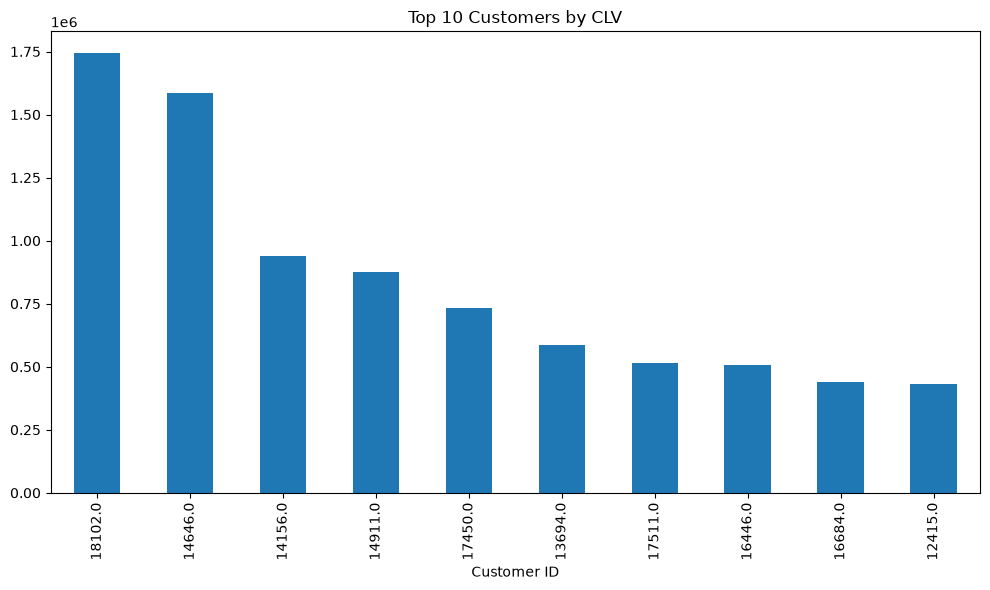

In [17]:
plt.figure(
    figsize=(10,6)
)

top_clv["CLV"].plot(
    kind="bar"
)

plt.title(
    "Top 10 Customers by CLV"
)

plt.tight_layout()

plt.savefig(
    "../Images/top_clv_customers.png"
)

plt.show()

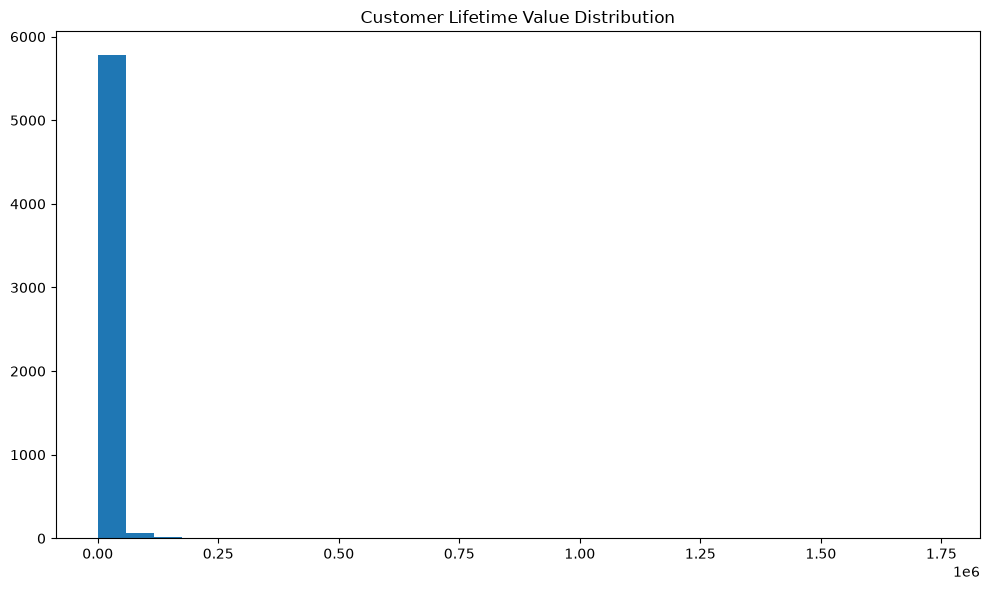

In [18]:
plt.figure(
    figsize=(10,6)
)

plt.hist(
    customer_summary["CLV"],
    bins=30
)

plt.title(
    "Customer Lifetime Value Distribution"
)

plt.tight_layout()

plt.savefig(
    "../Images/clv_distribution.png"
)

plt.show()

In [19]:
customer_summary["CLV"].describe()

count    5.878000e+03
mean     8.867712e+03
std      4.332256e+04
min      8.850000e+00
25%      1.026840e+03
50%      2.603220e+03
75%      6.744915e+03
max      1.742961e+06
Name: CLV, dtype: float64

In [21]:
customer_summary.to_csv(
    "../Dataset/final_clv_table.csv"
)

In [22]:
customer_summary.columns

Index(['Revenue', 'Orders', 'AOV', 'Purchase_Frequency', 'Lifespan', 'CLV'], dtype='str')

In [23]:
customer_summary.head()

,Revenue,Orders,AOV,Purchase_Frequency,Lifespan,CLV
Customer ID,,,,,,
12346.0,77556.46,12,6463.038333,12,3,232669.38
12347.0,4921.53,8,615.191250,8,3,14764.59
12348.0,2019.40,5,403.880000,5,3,6058.20
12349.0,4428.69,4,1107.172500,4,3,13286.07
12350.0,334.40,1,334.400000,1,3,1003.20


In [24]:
customer_summary["CLV"].describe()

count    5.878000e+03
mean     8.867712e+03
std      4.332256e+04
min      8.850000e+00
25%      1.026840e+03
50%      2.603220e+03
75%      6.744915e+03
max      1.742961e+06
Name: CLV, dtype: float64

In [25]:
print(
    customer_summary["CLV"].describe()
)

count    5.878000e+03
mean     8.867712e+03
std      4.332256e+04
min      8.850000e+00
25%      1.026840e+03
50%      2.603220e+03
75%      6.744915e+03
max      1.742961e+06
Name: CLV, dtype: float64


In [26]:
customer_summary["CLV"].head()


Customer ID
12346.0    232669.38
12347.0     14764.59
12348.0      6058.20
12349.0     13286.07
12350.0      1003.20
Name: CLV, dtype: float64

In [27]:
print(
    customer_summary["CLV"].describe()
)

count    5.878000e+03
mean     8.867712e+03
std      4.332256e+04
min      8.850000e+00
25%      1.026840e+03
50%      2.603220e+03
75%      6.744915e+03
max      1.742961e+06
Name: CLV, dtype: float64


In [28]:
top_clv.head(10)

,Revenue,Orders,AOV,Purchase_Frequency,Lifespan,CLV
Customer ID,,,,,,
18102.0,580987.04,145,4006.807172,145,3,1742961.12
14646.0,528602.52,151,3500.678940,151,3,1585807.56
14156.0,313437.62,156,2009.215513,156,3,940312.86
14911.0,291420.81,398,732.213090,398,3,874262.43
17450.0,244784.25,51,4799.691176,51,3,734352.75
13694.0,195640.69,143,1368.116713,143,3,586922.07
17511.0,172132.87,60,2868.881167,60,3,516398.61
16446.0,168472.50,2,84236.250000,2,3,505417.50
16684.0,147142.77,55,2675.323091,55,3,441428.31


In [29]:
print(
    customer_summary["CLV"].describe()
)


count    5.878000e+03
mean     8.867712e+03
std      4.332256e+04
min      8.850000e+00
25%      1.026840e+03
50%      2.603220e+03
75%      6.744915e+03
max      1.742961e+06
Name: CLV, dtype: float64


In [ ]:
print(
    customer_summary["CLV"].describe()
)